# The probability of passing a coin experiment

In [1]:
# Imports
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
def coin_experiment_demo(true_p=0.7, n_samples=10):
    """
    true_p: The hidden bias of the coin (unknown to students)
    n_samples: Number of times a student flips the coin to 'learn'
    """
    # 1. THE EXPERIMENT: Collect Realizations
    # 1 is Head, 0 is Tail
    tosses = np.random.binomial(1, true_p, n_samples)
    heads_observed = np.sum(tosses)
    
    # 2. THE ESTIMATION: Frequentist MLE
    p_hat = heads_observed / n_samples
    
    # 3. THE MODEL: Calculate P(Pass) = p^5
    true_pass_prob = true_p**5
    estimated_pass_prob = p_hat**5
    
    # --- Visualization ---
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plotting the function P(Pass) = p^5
    p_range = np.linspace(0, 1, 100)
    pass_probs = p_range**5
    ax.plot(p_range, pass_probs, label=r"Theoretical $P(Pass) = p^5$", color='black', lw=2)
    
    # Mark the Truth vs the Estimate
    ax.scatter([true_p], [true_pass_prob], color='black', s=100, label=f"True Logic (p={true_p})", zorder=5)
    ax.scatter([p_hat], [estimated_pass_prob], color='red', s=100, marker='x', label=f"Student Estimate (p̂={p_hat:.2f})", zorder=5)
    
    # Formatting
    ax.set_title(f"Scenario B: Estimating Success from {n_samples} Tosses", fontsize=14)
    ax.set_xlabel("Coin Bias (p)", fontsize=12)
    ax.set_ylabel("Probability of Passing Course", fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    print(f"Realizations: {tosses}")
    print(f"Heads Observed: {heads_observed}/{n_samples}")
    print(f"True Prob of Passing: {true_pass_prob:.4f}")
    print(f"Estimated Prob of Passing: {estimated_pass_prob:.4f}")
    
    plt.show()

Realizations: [0]
Heads Observed: 0/1
True Prob of Passing: 0.0312
Estimated Prob of Passing: 0.0000


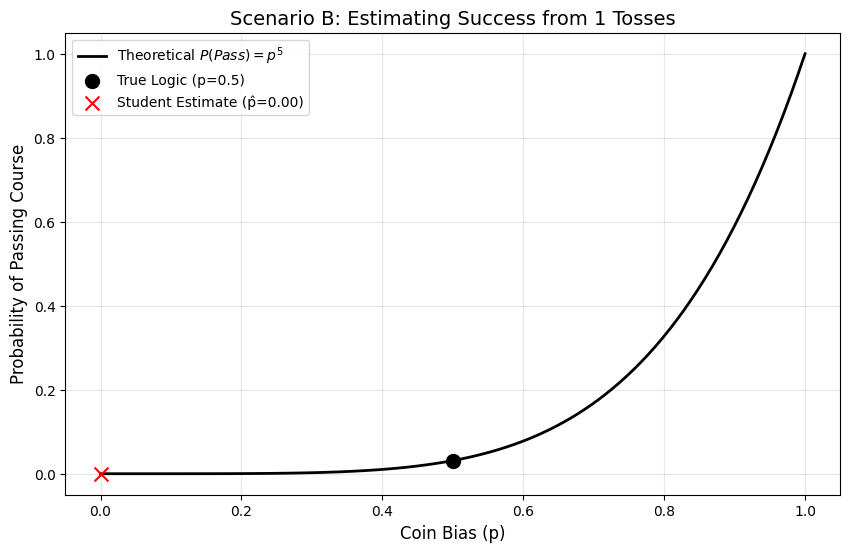

In [3]:
# Run the demo with fair coin, with 1 draw
coin_experiment_demo(true_p=0.5, n_samples=1)

Realizations: [0 1 1 1 0 1 0 1 1 1]
Heads Observed: 7/10
True Prob of Passing: 0.0312
Estimated Prob of Passing: 0.1681


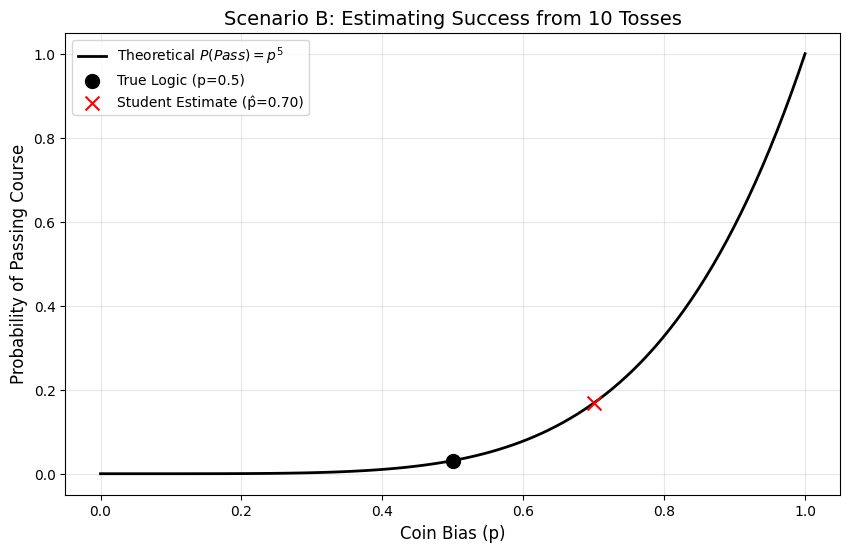

In [4]:
# Run the demo with fair coin, with 10 draws
coin_experiment_demo(true_p=0.5, n_samples=10)

Realizations: [1 1 1 1 1 0 1 1 1 1]
Heads Observed: 9/10
True Prob of Passing: 0.1681
Estimated Prob of Passing: 0.5905


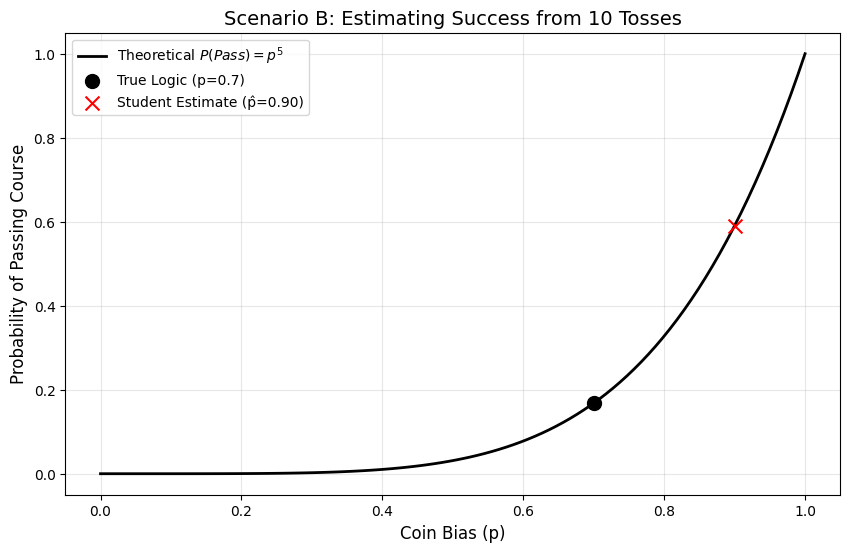

In [5]:
# Run the demo, with biased coin, with 10 draws
coin_experiment_demo(true_p=0.7, n_samples=10)

Realizations: [1 0 0 0 1 1 1 0 0 0]
Heads Observed: 4/10
True Prob of Passing: 0.0010
Estimated Prob of Passing: 0.0102


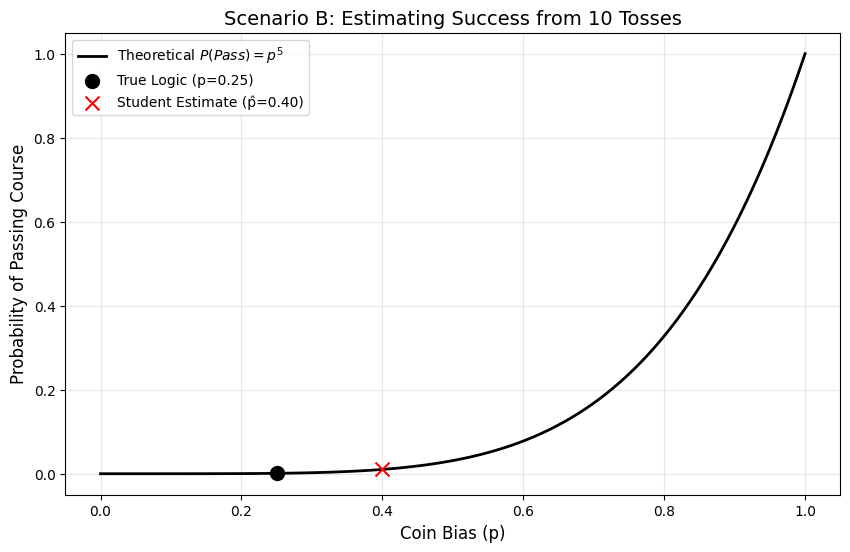

In [6]:
# Run the demo, with biased coin, with 10 draws
coin_experiment_demo(true_p=0.25, n_samples=10)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom

def bayesian_coin_demo(true_p=0.6, n_samples=10, alpha_prior=2, beta_prior=2):
    """
    alpha_prior, beta_prior: Parameters for the Beta distribution. 
    (2,2) is a weak 'fair coin' prior. (50,50) is a very strong 'fair coin' prior.
    """
    # 1. THE EXPERIMENT (Realizations)
    tosses = np.random.binomial(1, true_p, n_samples)
    heads = np.sum(tosses)
    tails = n_samples - heads
    
    # 2. ESTIMATION
    # Frequentist (MLE)
    p_mle = heads / n_samples
    
    # Bayesian (MAP estimate with Beta Prior)
    # The posterior of a Bernoulli with Beta prior is Beta(alpha + heads, beta + tails)
    # Prior map
    p_map_prior = (alpha_prior - 1) / (alpha_prior + beta_prior - 2)
    # Posterior map
    p_map_posterior = (heads + alpha_prior - 1) / (n_samples + alpha_prior + beta_prior - 2)
    
    # Print the realizations and estimates
    print(f"Realizations (1=Head, 0=Tail): {tosses}")
    print(f"Heads: {heads}, Tails: {tails}")
    print(f"True Coin Bias (p): {true_p}")
    print(f"Frequentist MLE Estimate (p̂): {p_mle:.2f}")
    print(f"Bayesian Prior MAP Estimate (p̂): {p_map_prior:.2f}")
    print(f"Bayesian Posterior MAP Estimate (p̂): {p_map_posterior:.2f}")
    
    # The Probability Landscape ---
    p_axis = np.linspace(0, 1, 100)
    
    # Theoretical Curve P(Pass) = p^5
    plt.title("Bayesian Coin Demo: Estimating p and P(Pass)")
    plt.plot(p_axis, p_axis**5, color='black', linestyle='--', alpha=0.5, label=r"Model: $P(Pass) = p^5$")
    
    # The Bayesian Prior-posterior Distributions
    prior_pdf = beta.pdf(p_axis, alpha_prior, beta_prior )
    plt.fill_between(p_axis, 0, prior_pdf / prior_pdf.max(), color='blue', alpha=0.2, label="Bayesian Posterior (Belief)")
    posterior_pdf = beta.pdf(p_axis, alpha_prior + heads, beta_prior + tails)
    plt.fill_between(p_axis, 0, posterior_pdf / posterior_pdf.max(), color='green', alpha=0.2, label="Bayesian Posterior (Belief)")
    
    # Mark the Estimates on the P(Pass) curve
    plt.scatter([true_p], [true_p**5], color='black', s=120, label=f"True Prob (p={true_p})", zorder=5)
    plt.scatter([p_mle], [p_mle**5], color='red', marker='x', s=120, label=f"MLE Estimate (p̂={p_mle:.2f})", zorder=5)
    # Prior MAP
    plt.scatter([p_map_prior], [p_map_prior**5], color='blue', marker='o', s=120, label=f"Prior MAP (p̂={p_map_prior:.2f})", zorder=5)
    # Posterior MAP
    plt.scatter([p_map_posterior], [p_map_posterior**5], color='green', marker='o', s=120, label=f"Posterior MAP (p̂={p_map_posterior:.2f})", zorder=5)
    
    plt.title("Probability of Passing: Truth vs. Estimates")
    plt.xlabel("Coin Bias (p)")
    plt.ylabel("Likelihood / Pass Prob")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Realizations (1=Head, 0=Tail): [1 1 0 0 1 1 1 1 1 1]
Heads: 8, Tails: 2
True Coin Bias (p): 0.7
Frequentist MLE Estimate (p̂): 0.80
Bayesian Prior MAP Estimate (p̂): 0.50
Bayesian Posterior MAP Estimate (p̂): 0.75


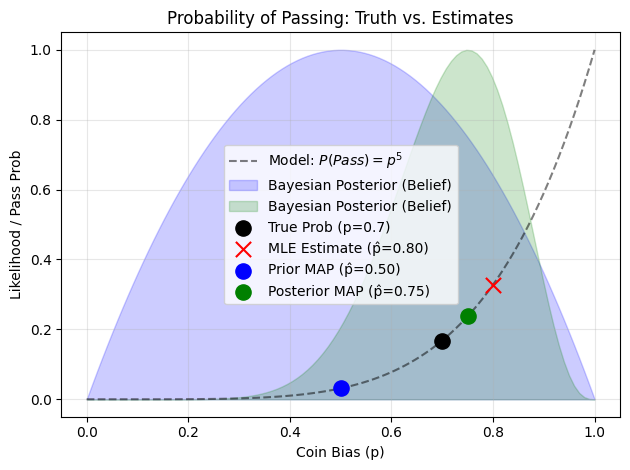

In [8]:
# Try with a small N to see the Bayesian 'Smoothing' effect
bayesian_coin_demo(true_p=0.7, n_samples=10)

Realizations (1=Head, 0=Tail): [1 0 1 1 1 0 1 1 1 0 1 1 0 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1
 0 0 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1
 0 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1]
Heads: 73, Tails: 27
True Coin Bias (p): 0.7
Frequentist MLE Estimate (p̂): 0.73
Bayesian Prior MAP Estimate (p̂): 0.50
Bayesian Posterior MAP Estimate (p̂): 0.73


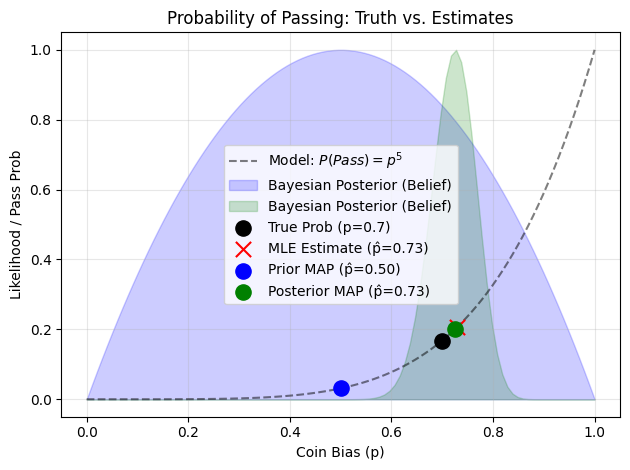

In [9]:
# Try with a larger N to see the Bayesian 'Smoothing' effect
bayesian_coin_demo(true_p=0.7, n_samples=100)

Realizations (1=Head, 0=Tail): [0 0 1 1 0 1 0 1 0 0]
Heads: 4, Tails: 6
True Coin Bias (p): 0.7
Frequentist MLE Estimate (p̂): 0.40
Bayesian Prior MAP Estimate (p̂): 0.50
Bayesian Posterior MAP Estimate (p̂): 0.49


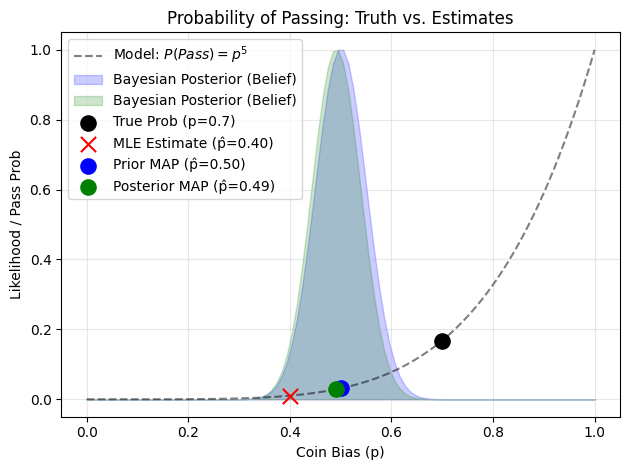

In [10]:
# Try with a strong prior to see the influence of the prior
bayesian_coin_demo(true_p=0.7, n_samples=10, alpha_prior=50, beta_prior=50)

Realizations (1=Head, 0=Tail): [1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1
 0 1 0 1 0 1 0 0 1 1 0 0 0 0 0 1 0 0 1 1 1 0 1 1 1 1]
Heads: 72, Tails: 28
True Coin Bias (p): 0.7
Frequentist MLE Estimate (p̂): 0.72
Bayesian Prior MAP Estimate (p̂): 0.50
Bayesian Posterior MAP Estimate (p̂): 0.61


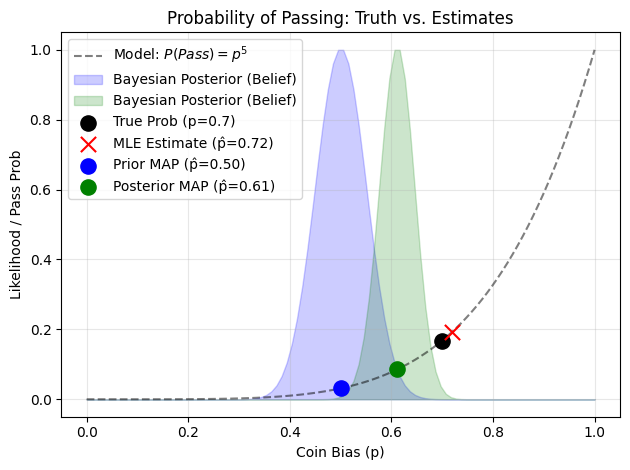

In [11]:
# Try with a strong prior, but the data is very different from the prior (to see the tension between data and prior)
bayesian_coin_demo(true_p=0.7, n_samples=100, alpha_prior=50, beta_prior=50)